Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer

Load Dataset

In [2]:
df = pd.read_csv("ecommerce_500k.csv")

print("Shape:", df.shape)
df.head()

Shape: (110033, 30)


,order_id,customer_id,product_id,order_date,category,sub_category,product_base_price,discount_percentage,final_price,quantity,...,city,loyalty_tier,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,return_reason,is_cancelled
0,1000001,25795,90,2022-07-31,Clothing,Men,70.41,25.0,52.81,1.0,...,Bangalore,Bronze,0.0,457.77,4.6,35.0,7.0,0.0,NaN,0.0
1,1000002,10860,1917,2023-09-25,Automotive,Car Care,6.02,10.0,5.42,3.0,...,Toronto,Bronze,0.0,1606.42,2.9,8.0,8.0,0.0,NaN,0.0
2,1000003,86820,805,2022-03-26,Books,Textbooks,78.85,20.0,63.08,2.0,...,Chicago,Silver,0.0,252.16,5.5,38.0,8.0,0.0,NaN,0.0
3,1000004,64886,3379,2022-11-03,Books,Non-Fiction,58.42,25.0,43.82,4.0,...,Sydney,Bronze,0.0,645.12,6.1,30.0,9.0,0.0,NaN,0.0
4,1000005,16265,4604,2022-06-30,Clothing,Women,73.38,15.0,62.37,1.0,...,Manchester,Bronze,1.0,1103.24,1.6,38.0,11.0,0.0,NaN,0.0


Basic Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110033 entries, 0 to 110032
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_id                 110033 non-null  int64  
 1   customer_id              110033 non-null  int64  
 2   product_id               110033 non-null  int64  
 3   order_date               110033 non-null  object 
 4   category                 110033 non-null  object 
 5   sub_category             110032 non-null  object 
 6   product_base_price       110032 non-null  float64
 7   discount_percentage      110032 non-null  float64
 8   final_price              110032 non-null  float64
 9   quantity                 110032 non-null  float64
 10  total_amount             110032 non-null  float64
 11  shipping_cost            106721 non-null  float64
 12  shipping_method          110032 non-null  object 
 13  days_to_deliver          106663 non-null  float64
 14  paym

Summary Statistics

In [4]:
df.describe(include="all")

,order_id,customer_id,product_id,order_date,category,sub_category,product_base_price,discount_percentage,final_price,quantity,...,city,loyalty_tier,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,return_reason,is_cancelled
count,1.100330e+05,110033.000000,110033.000000,110033,110033,110032,110032.00000,110032.000000,110032.000000,110032.000000,...,110032,110032,110032.000000,106670.000000,106865.000000,106715.000000,110032.000000,110032.000000,13027,110032.000000
unique,NaN,NaN,NaN,1095,11,45,NaN,NaN,NaN,NaN,...,15,4,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,NaN,2021-10-26,Food & Grocery,Outdoor,NaN,NaN,NaN,NaN,...,Dubai,Bronze,NaN,NaN,NaN,NaN,NaN,NaN,Better Price Found,NaN
freq,NaN,NaN,NaN,132,11067,6751,NaN,NaN,NaN,NaN,...,7454,49625,NaN,NaN,NaN,NaN,NaN,NaN,2660,NaN
mean,1.055017e+06,54959.298220,2510.045077,NaN,NaN,NaN,84.97245,14.620610,72.479139,2.284490,...,NaN,NaN,0.277765,850.359558,8.488824,24.964588,10.029555,0.118393,NaN,0.062509
std,3.176394e+04,26064.155924,1444.746968,NaN,NaN,NaN,80.28974,12.953759,69.929168,1.738411,...,NaN,NaN,0.447899,802.292143,8.058040,14.142712,5.471480,0.323074,NaN,0.242079
min,1.000001e+06,10001.000000,1.000000,NaN,NaN,NaN,5.00000,0.000000,2.500000,1.000000,...,NaN,NaN,0.000000,50.020000,0.500000,1.000000,1.000000,0.000000,NaN,0.000000
25%,1.027509e+06,32248.000000,1266.000000,NaN,NaN,NaN,27.86000,5.000000,23.380000,1.000000,...,NaN,NaN,0.000000,280.662500,2.800000,13.000000,5.000000,0.000000,NaN,0.000000
50%,1.055017e+06,55057.000000,2510.000000,NaN,NaN,NaN,60.16000,10.000000,50.450000,2.000000,...,NaN,NaN,0.000000,601.365000,6.000000,25.000000,10.000000,0.000000,NaN,0.000000
75%,1.082525e+06,77507.000000,3769.000000,NaN,NaN,NaN,115.68000,25.000000,98.350000,3.000000,...,NaN,NaN,1.000000,1157.157500,11.600000,37.000000,15.000000,0.000000,NaN,0.000000


Missing Values

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

return_reason              97006
days_to_deliver             3370
customer_lifetime_value     3363
customer_age                3361
pages_viewed                3318
rating                      3317
shipping_cost               3312
session_duration_mins       3168
sub_category                   1
shipping_method                1
total_amount                   1
final_price                    1
quantity                       1
discount_percentage            1
product_base_price             1
payment_method                 1
num_reviews                    1
loyalty_tier                   1
city                           1
country                        1
customer_gender                1
is_first_purchase              1
clicks_to_purchase             1
is_returned                    1
is_cancelled                   1
dtype: int64


Duplicate Rows

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


Price Distribution

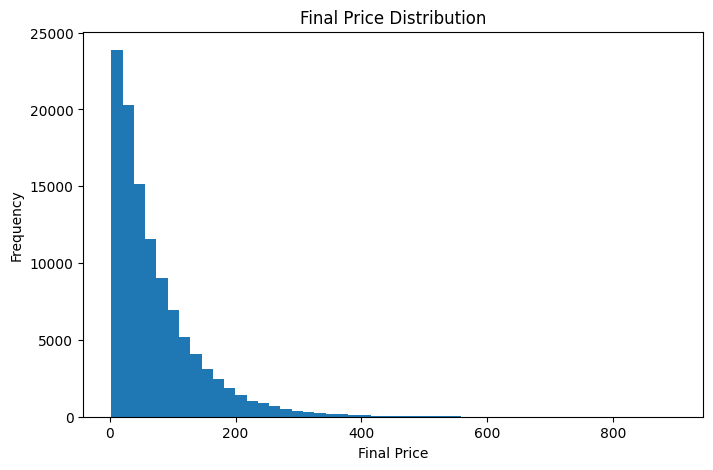

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["final_price"], bins=50)
plt.title("Final Price Distribution")
plt.xlabel("Final Price")
plt.ylabel("Frequency")
plt.show()

Skewness

In [8]:
print("Product Base Price Skew:", df["product_base_price"].skew())
print("Final Price Skew:", df["final_price"].skew())
print("Total Amount Skew:", df["total_amount"].skew())

Product Base Price Skew: 2.009092539714777
Final Price Skew: 2.09534035694913
Total Amount Skew: 4.1940492495740695


Categorical Columns

In [9]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print(categorical_cols)

['order_date', 'category', 'sub_category', 'shipping_method', 'payment_method', 'customer_gender', 'country', 'city', 'loyalty_tier', 'return_reason']


Cardinality

In [10]:
for col in categorical_cols:
    print(col, ":", df[col].nunique())

order_date : 1095
category : 11
sub_category : 45
shipping_method : 4
payment_method : 6
customer_gender : 3
country : 8
city : 15
loyalty_tier : 4
return_reason : 5


Return Rate

In [11]:
print(df["is_returned"].value_counts())
print(df["is_returned"].value_counts(normalize=True) * 100)

is_returned
0.0    97005
1.0    13027
Name: count, dtype: int64
is_returned
0.0    88.160717
1.0    11.839283
Name: proportion, dtype: float64


Loyalty Tier vs Returns

In [12]:
print(pd.crosstab(df["loyalty_tier"], df["is_returned"]))

is_returned     0.0   1.0
loyalty_tier             
Bronze        43678  5947
Gold          16613  2175
Platinum       7699  1052
Silver        29015  3853


Correlation

In [13]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

print(corr["is_returned"].sort_values(ascending=False))

is_returned                1.000000
customer_lifetime_value    0.002451
quantity                   0.001779
discount_percentage        0.001612
session_duration_mins      0.001282
pages_viewed               0.000828
final_price                0.000754
product_base_price         0.000348
order_id                   0.000289
days_to_deliver            0.000108
customer_age              -0.000625
clicks_to_purchase        -0.001126
num_reviews               -0.001480
total_amount              -0.001496
customer_id               -0.001770
shipping_cost             -0.002252
is_first_purchase         -0.006874
rating                    -0.007437
product_id                -0.009916
is_cancelled              -0.094627
Name: is_returned, dtype: float64


Feature Engineering Pipeline

In [14]:
numeric_cols = [
    "product_base_price",
    "final_price",
    "shipping_cost",
    "days_to_deliver",
    "rating",
    "customer_age",
    "customer_lifetime_value",
    "session_duration_mins",
    "pages_viewed"
]

robust_cols = ["total_amount"]

nominal_cols = [
    "category",
    "sub_category",
    "shipping_method",
    "payment_method",
    "customer_gender",
    "country"
]

ordinal_cols = ["loyalty_tier"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

robust_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=[["Bronze","Silver","Gold","Platinum"]]))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("robust", robust_pipeline, robust_cols),
    ("nominal", nominal_pipeline, nominal_cols),
    ("ordinal", ordinal_pipeline, ordinal_cols)
])

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['product_base_price', 'final_price',
                                  'shipping_cost', 'days_to_deliver', 'rating',
                                  'customer_age', 'customer_lifetime_value',
                                  'session_duration_mins', 'pages_viewed']),
                                ('robust',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
  